In [2]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np


## Load Dataset

In [ ]:
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [16]:
x_train[0].shape

(28, 28)

In [17]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

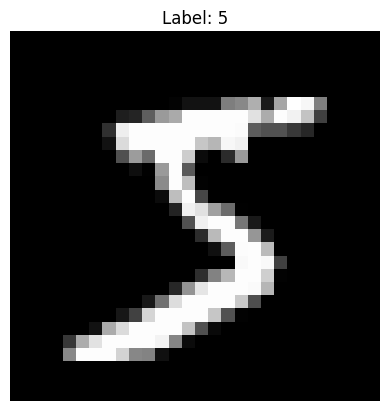

In [12]:
# Show first image
plt.imshow(x_train[0], cmap='gray')

# Show label
plt.title(f"Label: {y_train[0]}")

# Remove axis
plt.axis('off')

# Display image
plt.show()

## Shape

In [13]:
print(x_train.shape)
print(x_test.shape)


(60000, 28, 28)
(10000, 28, 28)


## Normalize

In [14]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## Model (Dense Network)

In [19]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation = "relu"),
    keras.layers.Dense(128, activation = "relu"),
    keras.layers.Dense(64, activation = "relu"),
    keras.layers.Dense(10, activation = "softmax"),
    
])

d:\SMIT\Machine Learning\DeepLearning\Beginner Level Projects\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer = "adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
) 

In [41]:
model.fit(x_train,y_train, epochs = 10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9972 - loss: 0.0110 - val_accuracy: 0.9899 - val_loss: 0.0385
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9977 - loss: 0.0077 - val_accuracy: 0.9915 - val_loss: 0.0390
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9973 - loss: 0.0100 - val_accuracy: 0.9889 - val_loss: 0.0456
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9973 - loss: 0.0095 - val_accuracy: 0.9829 - val_loss: 0.0930
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9970 - loss: 0.0101 - val_accuracy: 0.9853 - val_loss: 0.0771
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9976 - loss: 0.0090 - val_accuracy: 0.9864 - val_loss: 0.0612
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9978 - loss: 0.0086 - val_accuracy: 0.9878 - val_loss: 0.0601
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9977 - los

In [42]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9808 - loss: 0.1244


[0.12443408370018005, 0.9807999730110168]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


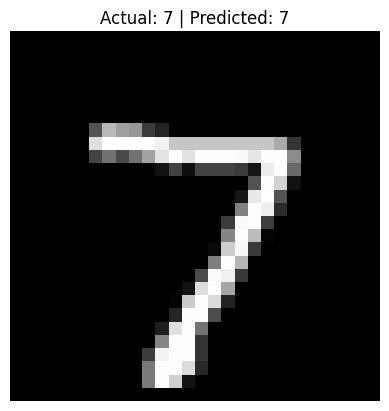

Prediction Probabilities:
[[4.7627261e-18 1.6555352e-10 2.2963180e-14 3.8015042e-13 5.1550392e-11
  3.3673763e-16 1.3859100e-19 1.0000000e+00 1.0663428e-13 8.2384126e-09]]


In [ ]:
test_image = x_test[0]

# Actual answer
actual_label = y_test[0]

# Predict
prediction = model.predict(test_image.reshape(1, 28, 28))

# Highest probability
predicted_label = np.argmax(prediction)

# =========================
# Show Image
# =========================
plt.imshow(test_image, cmap='gray')

plt.title(
    f"Actual: {actual_label} | Predicted: {predicted_label}"
)

plt.axis('off')
plt.show()

# Print probabilities
print("Prediction Probabilities:")
print(prediction)

## Test on Your Own Handwritten Digit

The cell below loads a local image file (`7.jpg`) and runs it through the trained model. To try this yourself:
1. Take a photo (or scan) of a digit you've written on paper.
2. Save it in this folder and update `image_path` below to point to it.
3. Run the cell — it will resize, invert, and normalize the image to match MNIST's format before predicting.

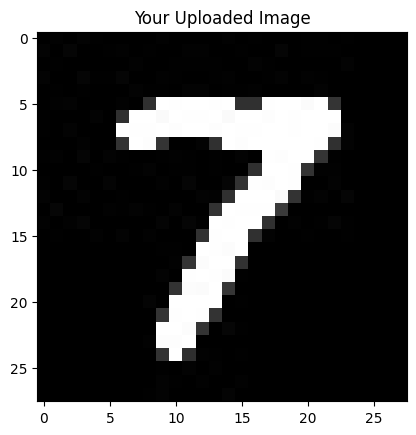

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Digit: 7
Probabilities:
[[2.4169665e-18 1.4347361e-07 3.7301760e-08 2.8999653e-04 3.1681885e-15
  1.1067005e-15 3.6795490e-25 9.9970990e-01 8.5217146e-12 8.2021688e-11]]


In [38]:
from PIL import Image

image_path = "7.jpg"

# Open image
img = Image.open(image_path).convert("L")

# Resize to 28x28
img = img.resize((28, 28))

# Convert to numpy array
img_array = np.array(img)

# Invert colors if needed
# (MNIST = white digit on black background)
img_array = 255 - img_array

# Normalize
img_array = img_array / 255.0

# Show image
plt.imshow(img_array, cmap='gray')
plt.title("Your Uploaded Image")
plt.show()

# Reshape for model
img_array = img_array.reshape(1, 28, 28)

# =========================
# 7. Predict Digit
# =========================
prediction = model.predict(img_array)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

# Show probabilities
print("Probabilities:")
print(prediction)